In [1]:
#%%time
import os
import re
import gzip
import math
import random
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt

from ast import literal_eval
import warnings
# 忽略 FutureWarning 类型警告
warnings.simplefilter(action='ignore', category=FutureWarning)
# 忽略特定类型的警告：忽略 scanpy包中含有 ignore 的 UserWarning 类型警告
warnings.filterwarnings("ignore", category=UserWarning, module="scanpy")
# 禁用 pandas 包中的 SettingWithCopyWarning 类型警告  
pd.options.mode.chained_assignment = None  # 或 'raise' 表示引发异常

import inferECC
from inferECC import *

species value: hg38
species == 'mm10':  False


In [2]:
def get_all_folders(path):
    folders = [f for f in os.listdir(path) if os.path.isdir(os.path.join(path, f))]
    return folders
"""
# 指定路径
target_path = library_dir # '/your/target/directory'
# 获取所有文件夹
folders_list = get_all_folders(target_path)
"""

"\n# 指定路径\ntarget_path = library_dir # '/your/target/directory'\n# 获取所有文件夹\nfolders_list = get_all_folders(target_path)\n"

In [3]:
df_ecdna_gene = pd.read_csv('./fig_cpr_rbg_stat_2/03.sc_sample/f09-df_ecdna_gene_oncogene.xls', sep='\t', index_col=0)
df_ecdna_gene

,Group,Significant Genes,DEG_number,chr_raw,genebody_region,genebody_region_gene,oncogene
0,C1,chr1:119900000_120000000,1311,chr1:119900000_120000000,2,"['RP5-1042I8.7', 'NOTCH2']",['NOTCH2']
0,C1,chr1:119800000_119900000,1311,chr1:119800000_119900000,5,"['REG4', 'NBPF7', 'PFN1P9', 'NOTCH2P1', 'ADAM30']",[]
0,C1,chr1:119600000_119700000,1311,chr1:119600000_119700000,3,"['HSD3BP5', 'ZNF697', 'PHGDH']",[]
0,C1,chr1:119700000_119800000,1311,chr1:119700000_119800000,3,"['PHGDH', 'HMGCS2', 'REG4']",[]
0,C1,chr1:119500000_119600000,1311,chr1:119500000_119600000,7,"['HSD3B1', 'GAPDHP32', 'HSD3BP3', 'GAPDHP27', ...",[]
...,...,...,...,...,...,...,...
10,other,chr7:100800000_100900000,6913,chr7:100800000_100900000,8,"['EPHB4', 'RN7SL750P', 'SLC12A9', 'RP11-126L15...",[]
10,other,chr19:40700000_40800000,6913,chr19:40700000_40800000,11,"['COQ8B', 'RNU6-195P', 'ITPKC', 'C19orf54', 'S...",[]
10,other,chr19:13700000_13800000,6913,chr19:13700000_13800000,7,"['CCDC130', 'MRI1', 'CTB-5E10.3', 'C19orf53', ...",[]
10,other,chr7:100100000_100200000,6913,chr7:100100000_100200000,13,"['MCM7', 'AP4M1', 'TAF6', 'RP11-506M12.1', 'CN...",[]


In [4]:
### 按照聚类提取 ecDNA 矩阵

In [5]:
combined_df = pd.read_csv(f"D:/02.project/18.ecDNA/02.code/v0.1.1/fig_cpr_rbg_stat_2/03.sc_sample/f05-df_cancer_sample-psdbulk_m3std_mtx-combined_df2.tsv", sep='\t',index_col=0)
combined_df

,BRCA_ht029b1-s1pc_C0,BRCA_ht029b1-s1pc_C1,BRCA_ht029b1-s1pc_C2,BRCA_ht029b1-s1pc_C3,BRCA_ht029b1-s1pc_C4,BRCA_ht029b1-s1pc_C5,BRCA_ht029b1-s1pc_C6,BRCA_ht029b1-s1pc_C7,BRCA_ht029b1-s1pc_C8,BRCA_ht029b1-s1pc_C9,...,UCEC_cpt704du-s1_C9,UCEC_cpt704du-t1_C0,UCEC_cpt704du-t1_C1,UCEC_cpt704du-t1_C2,UCEC_cpt704du-t1_C3,UCEC_cpt704du-t1_C4,UCEC_cpt704du-t1_C5,UCEC_cpt704du-t1_C6,UCEC_cpt704du-t1_C7,UCEC_cpt704du-t1_C8
chr_100k,,,,,,,,,,,,,,,,,,,,,
chr10:10000000_10100000,0.000000,0.000000,0.058147,0.128575,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
chr10:1000000_1100000,0.445358,0.544763,1.414967,0.630438,0.470342,0.359011,0.681936,0.702719,0.532338,0.0,...,0.0,0.000000,0.016471,0.0,0.0,0.0,0.0,0.0,0.0,0.0
chr10:100000_200000,0.127373,0.146104,0.373181,0.076083,0.000000,0.000000,0.039990,0.000000,0.000000,0.0,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
chr10:100100000_100200000,0.000000,0.000000,0.062860,0.000000,0.000000,0.118495,0.000000,0.000000,0.000000,0.0,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
chr10:100200000_100300000,0.000000,0.000000,0.081332,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,0.0,0.050707,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
chrX:92300000_92400000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
chr9:63500000_63600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
chrX:63100000_63200000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
cxe_mm = combined_df.copy().T
cxe_mm.columns = cxe_mm.columns.to_frame().chr_100k.to_list()
cxe_mm.columns.name = "cpr"
cxe_mm.index.name = "cancer_samp_clus"
### step 2
adata_can_samp = sc.AnnData(X = cxe_mm,
                          obs = cxe_mm.index.to_frame(),
                          var = cxe_mm.columns.to_frame())
#adata_can_samp.obs["can_samp"] = sample_name
adata_can_samp.obs.index.name = "clus_raw"
adata_can_samp

AnnData object with n_obs × n_vars = 1454 × 28421
    obs: 'cancer_samp_clus'
    var: 'cpr'

In [7]:
dendrogram_df2_str =pd.read_csv(f"./fig_cpr_rbg_stat_2/03.sc_sample/f07-tree-dendrogram_df2_str.tsv", sep='\t', index_col=0)

In [8]:
df_temp = adata_can_samp.obs.copy()
# Merge df1 and df2 on the 'col_same' column
df_temp = df_temp.merge(dendrogram_df2_str[['cancer_samp_clus', 'clus_group']], on='cancer_samp_clus', how='left')
df_temp.index = adata_can_samp.obs.index
adata_can_samp.obs = df_temp.copy()
adata_can_samp.obs

,cancer_samp_clus,clus_group
clus_raw,,
BRCA_ht029b1-s1pc_C0,BRCA_ht029b1-s1pc_C0,C1
BRCA_ht029b1-s1pc_C1,BRCA_ht029b1-s1pc_C1,C1
BRCA_ht029b1-s1pc_C2,BRCA_ht029b1-s1pc_C2,C1
BRCA_ht029b1-s1pc_C3,BRCA_ht029b1-s1pc_C3,C1
BRCA_ht029b1-s1pc_C4,BRCA_ht029b1-s1pc_C4,C1
...,...,...
UCEC_cpt704du-t1_C4,UCEC_cpt704du-t1_C4,C10
UCEC_cpt704du-t1_C5,UCEC_cpt704du-t1_C5,other
UCEC_cpt704du-t1_C6,UCEC_cpt704du-t1_C6,other


In [9]:
# 按照 cell_type 分组计算差异基因，给定基因排序
sc.tl.rank_genes_groups(adata_can_samp, groupby='clus_group', method='wilcoxon') 
# method::'t-test'/'t-test_overestim_var'/'wilcoxon'/'logreg'

In [10]:
### Significant DE ecdna cpr

In [11]:
import pandas as pd
# 计算差异基因
#sc.tl.rank_genes_groups(adata_can_samp, groupby='cancer', method='wilcoxon')

# 提取差异基因结果并筛选显著的基因
groups = adata_can_samp.uns['rank_genes_groups']['names'].dtype.names
DEG_dict = {}
DEG_dict_df = pd.DataFrame()
for group in groups:
    # 获取该group的p-values和基因名
    names = adata_can_samp.uns['rank_genes_groups']['names'][group]
    scores = adata_can_samp.uns['rank_genes_groups']['scores'][group]
    pvals = adata_can_samp.uns['rank_genes_groups']['pvals'][group]
    pvals_adj = adata_can_samp.uns['rank_genes_groups']['pvals_adj'][group]
    logfoldchanges = adata_can_samp.uns['rank_genes_groups']['logfoldchanges'][group]
    DEG_dict[group] = {"names":names.tolist(),
                       "scores":scores.tolist(),
                       "pvals":pvals.tolist(),
                       "pvals_adj":pvals_adj.tolist(),
                       "logfoldchanges":logfoldchanges.tolist()}
    DEG_dict_df_temp = pd.DataFrame(DEG_dict[group])
    DEG_dict_df_temp["group"] = group
    DEG_dict_df = pd.concat([DEG_dict_df, DEG_dict_df_temp], axis=0)


In [28]:
DEG_dict_df.to_csv('./fig_cpr_rbg_stat_2/06.circle-viz/f01-DEG_dict_df-all.xls', sep='\t', index=True)

In [ ]:
DEG_dict_df_padj = DEG_dict_df[(DEG_dict_df["pvals_adj"]<0.05)]
DEG_dict_df_padj["chr_raw"] = DEG_dict_df_padj["names"]
df_ecdna = DEG_dict_df_padj.copy()
df_ecdna_gene = genebody_region(df_fragments=df_ecdna,species="hg38")
df_ecdna_gene['oncogene'] = df_ecdna_gene['genebody_region_gene'].apply(custom_transform)

# 定义一个函数来计算每个元素的长度
def calculate_length(x):
    if isinstance(x, list):
        return len(x)
    else:
        return 0
# 应用函数并创建新的一列
DEG_dict_df_padj_onco = df_ecdna_gene.copy()
DEG_dict_df_padj_onco['oncogene_counts'] = DEG_dict_df_padj_onco['oncogene'].apply(calculate_length)
#DEG_dict_df_padj_onco.to_csv('./fig_cpr_rbg_stat_2/06.circle-viz/f02-DEG_dict_df_padj_onco.xls', sep='\t', index=True)
DEG_dict_df_padj_onco

In [3]:
DEG_dict_df_padj_onco = pd.read_csv('./fig_cpr_rbg_stat_2/06.circle-viz/f02-DEG_dict_df_padj_onco.xls', sep='\t', index_col=0)
DEG_dict_df_padj_onco

,names,scores,pvals,pvals_adj,logfoldchanges,group,chr_raw,genebody_region,genebody_region_gene,oncogene,oncogene_counts
0,chr1:119900000_120000000,5.393137,6.923816e-08,1.428030e-03,8.016695,C1,chr1:119900000_120000000,2,"['RP5-1042I8.7', 'NOTCH2']",['NOTCH2'],1
1,chr1:119800000_119900000,5.156784,2.512280e-07,1.428030e-03,7.283999,C1,chr1:119800000_119900000,5,"['REG4', 'NBPF7', 'PFN1P9', 'NOTCH2P1', 'ADAM30']",[],0
2,chr1:119600000_119700000,4.968312,6.753824e-07,1.810314e-03,5.930417,C1,chr1:119600000_119700000,3,"['HSD3BP5', 'ZNF697', 'PHGDH']",[],0
3,chr1:119700000_119800000,4.919615,8.671459e-07,1.903690e-03,6.013848,C1,chr1:119700000_119800000,3,"['PHGDH', 'HMGCS2', 'REG4']",[],0
4,chr1:119500000_119600000,4.918800,8.707637e-07,1.903690e-03,6.026254,C1,chr1:119500000_119600000,7,"['HSD3B1', 'GAPDHP32', 'HSD3BP3', 'GAPDHP27', ...",[],0
...,...,...,...,...,...,...,...,...,...,...,...
28416,chr7:100800000_100900000,-11.300375,1.306585e-29,7.426890e-26,-1.414721,other,chr7:100800000_100900000,8,"['EPHB4', 'RN7SL750P', 'SLC12A9', 'RP11-126L15...",[],0
28417,chr19:40700000_40800000,-11.384850,4.975430e-30,3.535168e-26,-1.840123,other,chr19:40700000_40800000,11,"['COQ8B', 'RNU6-195P', 'ITPKC', 'C19orf54', 'S...",[],0
28418,chr19:13700000_13800000,-11.523119,1.008919e-30,9.558167e-27,-1.662528,other,chr19:13700000_13800000,7,"['CCDC130', 'MRI1', 'CTB-5E10.3', 'C19orf53', ...",[],0
28419,chr7:100100000_100200000,-11.534023,8.889041e-31,9.558167e-27,-1.546449,other,chr7:100100000_100200000,13,"['MCM7', 'AP4M1', 'TAF6', 'RP11-506M12.1', 'CN...",[],0


In [5]:
DEG_dict_df_padj_onco.groupby("group").size()

group
C1        132
C10       634
C2       2473
C3        504
C4       1727
C5       1524
C6        133
C7        690
C8         44
C9       8953
other    5464
dtype: int64

In [34]:
DEG_dict_df_padj_onco_sig = DEG_dict_df_padj_onco[(DEG_dict_df_padj_onco["pvals_adj"]<0.05) & (DEG_dict_df_padj_onco["logfoldchanges"]>2)]
DEG_dict_df_padj_onco_sig

,names,scores,pvals,pvals_adj,logfoldchanges,group,chr_raw,genebody_region,genebody_region_gene,oncogene,oncogene_counts
0,chr1:119900000_120000000,5.393137,6.923816e-08,0.001428,8.016695,C1,chr1:119900000_120000000,2,"[RP5-1042I8.7, NOTCH2]",[NOTCH2],1
1,chr1:119800000_119900000,5.156784,2.512280e-07,0.001428,7.283999,C1,chr1:119800000_119900000,5,"[REG4, NBPF7, PFN1P9, NOTCH2P1, ADAM30]",[],0
2,chr1:119600000_119700000,4.968312,6.753824e-07,0.001810,5.930417,C1,chr1:119600000_119700000,3,"[HSD3BP5, ZNF697, PHGDH]",[],0
3,chr1:119700000_119800000,4.919615,8.671459e-07,0.001904,6.013848,C1,chr1:119700000_119800000,3,"[PHGDH, HMGCS2, REG4]",[],0
4,chr1:119500000_119600000,4.918800,8.707637e-07,0.001904,6.026254,C1,chr1:119500000_119600000,7,"[HSD3B1, GAPDHP32, HSD3BP3, GAPDHP27, HSD3BP4,...",[],0
...,...,...,...,...,...,...,...,...,...,...,...
597,chrX:153300000_153400000,3.331561,8.636040e-04,0.040976,2.330266,C10,chrX:153300000_153400000,4,"[LL0XNC01-16G2.1, ZNF275, LL0XNC01-37G1.2, U82...",[],0
604,chr1:63600000_63700000,3.315952,9.133143e-04,0.042834,2.218765,C10,chr1:63600000_63700000,2,"[PGM1, RN7SL130P]",[],0
609,chr15:80800000_80900000,3.311125,9.292174e-04,0.043223,2.001976,C10,chr15:80800000_80900000,4,"[CEMIP, MIR549A, RP11-351M8.2, RP11-351M8.1]",[],0
612,chr22:32800000_32900000,3.305976,9.464633e-04,0.043810,2.609737,C10,chr22:32800000_32900000,2,"[SYN3, TIMP3]",[],0


In [35]:
DEG_dict_df_padj_onco_sig.groupby("group").size()

group
C1      11
C10    117
C2      19
C3      23
C4     197
C5     167
C6      18
C7      75
C8      31
C9      88
dtype: int64

In [68]:
DEG_dict_df_padj_onco = DEG_dict_df_padj_onco.drop(['chr_raw', 'genebody_region_gene'], axis=1)

In [184]:
df_C1 = DEG_dict_df_padj_onco[
(DEG_dict_df_padj_onco["pvals_adj"]<0.05) 
& (DEG_dict_df_padj_onco["scores"]>0) 
& (DEG_dict_df_padj_onco["logfoldchanges"]>2) 
& (DEG_dict_df_padj_onco["group"]=="C1") 
#& (DEG_dict_df_padj_onco["oncogene_counts"]>=1)
]
df_C1

,names,scores,pvals,pvals_adj,logfoldchanges,group,genebody_region,oncogene,oncogene_counts
0,chr1:119900000_120000000,5.393137,6.923816e-08,0.001428,8.016695,C1,2,[NOTCH2],1
1,chr1:119800000_119900000,5.156784,2.512280e-07,0.001428,7.283999,C1,5,[],0
2,chr1:119600000_119700000,4.968312,6.753824e-07,0.001810,5.930417,C1,3,[],0
3,chr1:119700000_119800000,4.919615,8.671459e-07,0.001904,6.013848,C1,3,[],0
4,chr1:119500000_119600000,4.918800,8.707637e-07,0.001904,6.026254,C1,7,[],0
5,chr1:120100000_120200000,4.600742,4.209893e-06,0.005439,7.899948,C1,3,[],0
6,chr13:110400000_110500000,4.237247,2.262778e-05,0.015410,4.437501,C1,3,[],0
7,chr1:119200000_119300000,4.152689,3.285913e-05,0.017889,6.096661,C1,3,[],0
8,chr12:6400000_6500000,4.064260,4.818506e-05,0.021166,3.427047,C1,10,[],0
9,chr13:110300000_110400000,4.008432,6.112328e-05,0.024998,3.275916,C1,3,[],0


In [185]:
df_C2 = DEG_dict_df_padj_onco[
(DEG_dict_df_padj_onco["pvals_adj"]<0.05) 
& (DEG_dict_df_padj_onco["scores"]>0) 
& (DEG_dict_df_padj_onco["logfoldchanges"]>2) 
& (DEG_dict_df_padj_onco["group"]=="C2") 
#& (DEG_dict_df_padj_onco["oncogene_counts"]>=1)
]
df_C2

,names,scores,pvals,pvals_adj,logfoldchanges,group,genebody_region,oncogene,oncogene_counts
0,chr11:67000000_67100000,6.052903,1.422585e-09,5.101151e-07,2.839230,C2,3,[],0
1,chr11:70100000_70200000,5.987552,2.130233e-09,6.599474e-07,3.874906,C2,3,[],0
2,chr11:69300000_69400000,5.977755,2.262341e-09,6.913762e-07,3.258306,C2,3,[],0
3,chr11:70200000_70300000,5.826881,5.647264e-09,1.304885e-06,3.651980,C2,6,[],0
5,chr17:39900000_40000000,4.373475,1.222843e-05,4.840449e-04,4.059834,C2,6,[],0
6,chr11:69900000_70000000,4.246115,2.175095e-05,7.511346e-04,2.708326,C2,3,[],0
7,chr11:69600000_69700000,4.051097,5.097796e-05,1.484472e-03,2.401178,C2,4,[CCND1],1
8,chr11:69100000_69200000,4.040263,5.339124e-05,1.537419e-03,2.422419,C2,4,[],0
9,chr11:66900000_67000000,3.976295,6.999732e-05,1.898276e-03,2.906545,C2,4,[],0
11,chr11:69400000_69500000,3.694949,2.199305e-04,4.764211e-03,2.472248,C2,5,[],0


In [186]:
df_C3 = DEG_dict_df_padj_onco[
(DEG_dict_df_padj_onco["pvals_adj"]<0.05) 
& (DEG_dict_df_padj_onco["scores"]>0) 
& (DEG_dict_df_padj_onco["logfoldchanges"]>2) 
& (DEG_dict_df_padj_onco["group"]=="C3") 
#& (DEG_dict_df_padj_onco["oncogene_counts"]>=1)
]
df_C3

,names,scores,pvals,pvals_adj,logfoldchanges,group,genebody_region,oncogene,oncogene_counts
0,chr19:38800000_38900000,16.118616,1.887901e-58,5.365604e-54,4.047583,C3,10,[],0
1,chr19:38300000_38400000,15.020510,5.389150e-51,7.658252e-47,4.224973,C3,10,[],0
2,chr19:38600000_38700000,14.117661,2.956391e-45,2.800786e-41,3.820956,C3,5,[],0
3,chr19:38200000_38300000,12.927728,3.139616e-38,2.230776e-34,3.461381,C3,7,[],0
4,chr19:38700000_38800000,12.040312,2.181298e-33,1.239894e-29,3.414770,C3,6,[],0
5,chr19:39300000_39400000,10.936405,7.720085e-28,3.656875e-24,3.406967,C3,8,[],0
6,chr19:33000000_33100000,9.779305,1.381551e-22,5.609294e-19,2.358281,C3,4,[],0
7,chr19:37900000_38000000,8.636654,5.788352e-18,2.056384e-14,2.637593,C3,3,[],0
8,chr19:39400000_39500000,8.528736,1.479547e-17,4.672245e-14,2.684826,C3,8,[],0
10,chr19:38900000_39000000,7.723189,1.134549e-14,2.931365e-11,2.673573,C3,8,[],0


In [237]:
df_C4 = DEG_dict_df_padj_onco[
(DEG_dict_df_padj_onco["pvals_adj"]<1e-3) 
&(DEG_dict_df_padj_onco["logfoldchanges"]>2.2)
& (DEG_dict_df_padj_onco["scores"]>0) 
& (DEG_dict_df_padj_onco["group"]=="C4") 
& ((DEG_dict_df_padj_onco["oncogene_counts"]>=1)|((DEG_dict_df_padj_onco["logfoldchanges"]>2.5)&(DEG_dict_df_padj_onco["pvals_adj"]<=2e-6) ))
]
df_C4

,names,scores,pvals,pvals_adj,logfoldchanges,group,genebody_region,oncogene,oncogene_counts
1,chr10:77800000_77900000,10.360158,3.763383e-25,5.347956e-21,2.973288,C4,2,[],0
14,chr10:8000000_8100000,8.352612,6.676971e-17,1.265108e-13,2.424924,C4,4,[GATA3],1
16,chr14:100000000_100100000,8.303172,1.013681e-16,1.694695e-13,2.662936,C4,2,[],0
26,chr4:140600000_140700000,7.843506,4.381365e-15,4.611954e-12,2.995476,C4,3,[],0
33,chr4:14800000_14900000,7.657041,1.902667e-14,1.590462e-11,2.908651,C4,1,[],0
48,chr15:70300000_70400000,7.261733,3.821634e-13,2.216625e-10,2.548547,C4,1,[],0
60,chr7:70700000_70800000,7.019433,2.227700e-12,1.037926e-09,2.960610,C4,1,[],0
66,chr15:98700000_98800000,6.819329,9.146698e-12,3.879975e-09,3.409348,C4,2,[],0
78,chr18:76400000_76500000,6.552629,5.653288e-11,2.033824e-08,3.264646,C4,3,[],0
85,chr15:71100000_71200000,6.495837,8.257320e-11,2.720494e-08,2.549526,C4,4,[],0


In [254]:
df_C4 = DEG_dict_df_padj_onco[
(((DEG_dict_df_padj_onco["pvals_adj"]<5e-2) 
& (DEG_dict_df_padj_onco["logfoldchanges"]>3)
& (DEG_dict_df_padj_onco["scores"]>3) 
& (DEG_dict_df_padj_onco["oncogene_counts"]>=1))|
((DEG_dict_df_padj_onco["pvals_adj"]<5e-3) 
& (DEG_dict_df_padj_onco["logfoldchanges"]>2.1)
& (DEG_dict_df_padj_onco["scores"]>4) 
& (DEG_dict_df_padj_onco["oncogene_counts"]>=1)))
& (DEG_dict_df_padj_onco["group"]=="C4")
]
df_C4

,names,scores,pvals,pvals_adj,logfoldchanges,group,genebody_region,oncogene,oncogene_counts
3,chr15:90100000_90200000,10.198199,2.019824e-24,1.435136e-20,2.153816,C4,4,[IDH2],1
14,chr10:8000000_8100000,8.352612,6.676971e-17,1.265108e-13,2.424924,C4,4,[GATA3],1
155,chr14:37500000_37600000,5.946881,2.733004e-09,4.947433e-07,2.411598,C4,5,[FOXA1],1
159,chr11:114100000_114200000,5.931111,3.008916e-09,5.311579e-07,2.320758,C4,1,[ZBTB16],1
172,chr17:5200000_5300000,5.801651,6.566538e-09,1.072572e-06,2.176511,C4,4,[RABEP1],1
252,chr6:151800000_151900000,5.434792,5.486046e-08,6.129099e-06,2.300798,C4,2,[ESR1],1
282,chr2:100000000_100100000,5.303520,1.135909e-07,1.136749e-05,3.118160,C4,1,[AFF3],1
320,chr6:152000000_152100000,5.165002,2.404362e-07,2.122186e-05,2.727638,C4,1,[ESR1],1
375,chr6:151600000_151700000,4.991748,5.983513e-07,4.498874e-05,2.240460,C4,3,[ESR1],1
423,chr11:114000000_114100000,4.847903,1.247732e-06,8.304868e-05,2.115814,C4,1,[ZBTB16],1


In [214]:
df_C5 = DEG_dict_df_padj_onco[
(DEG_dict_df_padj_onco["pvals_adj"]<5e-15) 
& (DEG_dict_df_padj_onco["scores"]>0) 
& (DEG_dict_df_padj_onco["group"]=="C5") 
& ((DEG_dict_df_padj_onco["oncogene_counts"]>=1)|(DEG_dict_df_padj_onco["logfoldchanges"]>3))
]
df_C5

,names,scores,pvals,pvals_adj,logfoldchanges,group,genebody_region,oncogene,oncogene_counts
0,chr22:37900000_38000000,14.900050,3.293315e-50,9.359931e-46,3.136851,C5,7,[],0
1,chr22:38000000_38100000,14.339055,1.247417e-46,1.772642e-42,3.639838,C5,9,[],0
2,chr1:236100000_236200000,12.380972,3.313075e-35,3.138697e-31,3.143455,C5,2,[],0
3,chr17:76500000_76600000,11.693871,1.369959e-31,7.787124e-28,3.246928,C5,13,[],0
7,chr3:49400000_49500000,11.290832,1.456514e-29,4.599509e-26,1.939338,C5,7,[RHOA],1
10,chr6:15400000_15500000,10.967580,5.471746e-28,1.295937e-24,3.600184,C5,1,[],0
11,chr7:22800000_22900000,10.905499,1.084965e-27,2.371983e-24,3.766484,C5,6,[],0
16,chr1:116400000_116500000,10.408204,2.274717e-25,3.591652e-22,2.419906,C5,6,[ATP1A1],1
20,chr19:600000_700000,10.112160,4.879654e-24,6.303848e-21,1.604099,C5,9,[FSTL3],1
27,chr3:98700000_98800000,9.597158,8.217860e-22,8.053787e-19,3.250981,C5,4,[],0


In [198]:
df_C6 = DEG_dict_df_padj_onco[
(DEG_dict_df_padj_onco["pvals_adj"]<5e-2) 
& (DEG_dict_df_padj_onco["scores"]>0) 
& (DEG_dict_df_padj_onco["group"]=="C6") 
& ((DEG_dict_df_padj_onco["oncogene_counts"]>=1)|(DEG_dict_df_padj_onco["logfoldchanges"]>2))
]
df_C6

,names,scores,pvals,pvals_adj,logfoldchanges,group,genebody_region,oncogene,oncogene_counts
0,chr8:133200000_133300000,8.490973,2.049155e-17,5.823904e-13,2.768364,C6,3,[NDRG1],1
3,chr8:133300000_133400000,6.062065,1.343852e-09,7.638723e-06,2.167522,C6,3,[NDRG1],1
4,chr2:118800000_118900000,5.943694,2.786701e-09,1.320014e-05,2.338230,C6,2,[],0
6,chr8:123500000_123600000,5.845205,5.059450e-09,1.797433e-05,2.927849,C6,3,[],0
13,chr8:134700000_134800000,5.105354,3.301760e-07,4.468539e-04,2.519315,C6,5,[],0
15,chr8:127700000_127800000,4.917725,8.755586e-07,9.953701e-04,2.043237,C6,4,"[PVT1, MYC]",2
16,chr18:13200000_13300000,4.850310,1.232686e-06,1.186985e-03,2.234430,C6,5,[],0
19,chr8:123600000_123700000,4.777102,1.778398e-06,1.529995e-03,2.569028,C6,3,[],0
20,chr8:116900000_117000000,4.771308,1.830331e-06,1.529995e-03,2.986219,C6,2,[],0
21,chr8:66500000_66600000,4.675189,2.936822e-06,2.365963e-03,3.023086,C6,3,[MYBL1],1


In [199]:
df_C7 = DEG_dict_df_padj_onco[
(DEG_dict_df_padj_onco["pvals_adj"]<1e-3) 
& (DEG_dict_df_padj_onco["logfoldchanges"]>2)
& (DEG_dict_df_padj_onco["scores"]>0) 
& (DEG_dict_df_padj_onco["group"]=="C7") 
& ((DEG_dict_df_padj_onco["oncogene_counts"]>=1)|(DEG_dict_df_padj_onco["logfoldchanges"]>2.5))
]
df_C7

,names,scores,pvals,pvals_adj,logfoldchanges,group,genebody_region,oncogene,oncogene_counts
0,chr20:62400000_62500000,13.736840,6.108381e-43,1.736063e-38,2.994335,C7,6,[],0
1,chr20:63500000_63600000,13.438002,3.620852e-41,5.145412e-37,2.427256,C7,8,[PTK6],1
2,chr20:50300000_50400000,13.388957,7.015938e-41,6.646666e-37,2.524723,C7,2,[],0
3,chr20:62600000_62700000,13.169711,1.310988e-39,9.314896e-36,2.913149,C7,9,[],0
4,chr7:900000_1000000,12.829101,1.126645e-37,6.404076e-34,2.668784,C7,4,[],0
5,chr20:44300000_44400000,12.652457,1.084300e-36,5.136147e-33,4.554406,C7,6,[],0
6,chr13:27900000_28000000,12.334498,5.905535e-35,2.260966e-31,4.011761,C7,7,[CDX2],1
10,chr20:51700000_51800000,12.017787,2.865425e-33,7.403476e-30,2.782843,C7,3,[SALL4],1
12,chr20:44400000_44500000,11.740872,7.867066e-32,1.719922e-28,3.442244,C7,6,[],0
15,chr20:57500000_57600000,11.152546,6.958666e-29,1.236077e-25,3.132546,C7,3,[],0


In [200]:
df_C8 = DEG_dict_df_padj_onco[
(DEG_dict_df_padj_onco["pvals_adj"]<5e-2) 
#& (DEG_dict_df_padj_onco["logfoldchanges"]>2)
& (DEG_dict_df_padj_onco["scores"]>0) 
& (DEG_dict_df_padj_onco["group"]=="C8") 
#& ((DEG_dict_df_padj_onco["oncogene_counts"]>=1)|(DEG_dict_df_padj_onco["logfoldchanges"]>2.5))
]
df_C8

,names,scores,pvals,pvals_adj,logfoldchanges,group,genebody_region,oncogene,oncogene_counts
0,chr3:184300000_184400000,6.832288,8.357062e-12,2.375161e-07,3.110198,C8,8,[],0
1,chr3:183900000_184000000,6.540821,6.118201e-11,8.694269e-07,3.887342,C8,2,[],0
2,chr3:185900000_186000000,5.960612,2.512946e-09,2.380681e-05,4.198096,C8,2,[],0
3,chr3:196100000_196200000,5.895189,3.742519e-09,2.659153e-05,1.938701,C8,2,[],0
4,chr3:189300000_189400000,5.798942,6.673450e-09,3.793323e-05,3.713096,C8,1,[],0
5,chr3:181900000_182000000,5.550251,2.852591e-08,1.351225e-04,4.769394,C8,2,[],0
6,chr3:194100000_194200000,5.502442,3.745657e-08,1.520790e-04,1.858625,C8,4,[],0
7,chr3:153100000_153200000,5.394033,6.889344e-08,2.131995e-04,2.093279,C8,4,[],0
8,chr3:150700000_150800000,5.390678,7.019224e-08,2.131995e-04,2.198095,C8,5,[],0
9,chr3:194600000_194700000,5.378726,7.501477e-08,2.131995e-04,3.285217,C8,5,[],0


In [201]:
df_C9 = DEG_dict_df_padj_onco[
(DEG_dict_df_padj_onco["pvals_adj"]<5e-2) 
& (DEG_dict_df_padj_onco["logfoldchanges"]>2)
& (DEG_dict_df_padj_onco["scores"]>0) 
& (DEG_dict_df_padj_onco["group"]=="C9") 
& ((DEG_dict_df_padj_onco["oncogene_counts"]>=1)|(DEG_dict_df_padj_onco["logfoldchanges"]>2.5))
]
df_C9

,names,scores,pvals,pvals_adj,logfoldchanges,group,genebody_region,oncogene,oncogene_counts
1,chr3:195800000_195900000,15.726980,9.881304e-56,1.404183e-51,2.218087,C9,5,[MUC4],1
4,chr4:1700000_1800000,15.529208,2.200790e-54,1.250973e-50,2.267610,C9,5,[FGFR3],1
23,chr19:10500000_10600000,14.875662,4.742711e-50,5.616358e-47,2.300881,C9,9,[KEAP1],1
62,chr19:3100000_3200000,14.046877,8.050670e-45,3.631875e-42,2.176383,C9,8,[GNA11],1
165,chr18:9600000_9700000,12.886855,5.337613e-38,9.124765e-36,2.827975,C9,4,[],0
469,chr9:95000000_95100000,11.603335,3.963254e-31,2.396588e-29,2.021323,C9,6,[FANCC],1
641,chr3:122300000_122400000,11.055174,2.069349e-28,9.160897e-27,2.558114,C9,4,[],0
1059,chr3:185300000_185400000,9.984505,1.781882e-23,4.777628e-22,2.094266,C9,1,[MAP3K13],1
1060,chr18:63400000_63500000,9.982425,1.819642e-23,4.874273e-22,2.543980,C9,5,[],0
1188,chr3:189900000_190000000,9.667829,4.130500e-22,9.873250e-21,2.548181,C9,2,[],0


In [221]:
df_C10 = DEG_dict_df_padj_onco[
(DEG_dict_df_padj_onco["pvals_adj"]<5e-5) 
& (DEG_dict_df_padj_onco["logfoldchanges"]>2)
& (DEG_dict_df_padj_onco["scores"]>0) 
& (DEG_dict_df_padj_onco["group"]=="C10") 
& ((DEG_dict_df_padj_onco["oncogene_counts"]>=1)|(DEG_dict_df_padj_onco["logfoldchanges"]>2.5))
]
df_C10

,names,scores,pvals,pvals_adj,logfoldchanges,group,genebody_region,oncogene,oncogene_counts
0,chr2:113200000_113300000,8.180057,2.837097e-16,8.063314e-12,2.956237,C10,3,[PAX8],1
2,chr2:217900000_218000000,7.732395,1.055422e-14,7.998284e-11,2.701318,C10,3,[],0
3,chr4:3700000_3800000,7.724188,1.125686e-14,7.998284e-11,3.066976,C10,2,[],0
5,chr4:3600000_3700000,7.353281,1.933991e-13,9.160993e-10,3.391161,C10,2,[],0
10,chr19:58000000_58100000,6.779141,1.208927e-11,3.123538e-08,2.693522,C10,9,[],0
14,chr4:1600000_1700000,6.382005,1.747839e-10,3.111242e-07,3.114035,C10,2,[],0
34,chr5:171400000_171500000,5.733844,9.817953e-09,7.877895e-06,2.515635,C10,2,[NPM1],1
35,chr3:13600000_13700000,5.730948,9.987103e-09,7.877895e-06,2.069431,C10,2,[FBLN2],1
36,chr19:29000000_29100000,5.726442,1.025587e-08,7.877895e-06,3.061641,C10,2,[],0
48,chr4:8300000_8400000,5.491186,3.992435e-08,2.302702e-05,2.539601,C10,6,[],0


In [203]:
outfile_path = "D:/02.project/18.ecDNA/02.code/v0.1.1/fig_cpr_rbg_stat_2/06.circle-viz"
if(os.path.exists(outfile_path) != True): os.makedirs(outfile_path)
os.chdir(outfile_path)
print(os.getcwd())

#### generate circle viz pre-files
### import generate_circle_viz_pre_files function

D:\02.project\18.ecDNA\02.code\v0.1.1\fig_cpr_rbg_stat_2\06.circle-viz


In [255]:
circle_graph_file(df=df_C4,outfile_path="D:/02.project/18.ecDNA/02.code/v0.1.1/fig_cpr_rbg_stat_2/06.circle-viz/C4")

D:\02.project\18.ecDNA\02.code\v0.1.1\fig_cpr_rbg_stat_2\06.circle-viz\C4
Done: amplicon_cycles.txt
Done: amplicon_graph.txt


In [249]:
DEG_dict_df_padj_onco[#(DEG_dict_df_padj_onco["pvals_adj"]<0.05) & 
#(DEG_dict_df_padj_onco["logfoldchanges"]>0) &
(DEG_dict_df_padj_onco["names"].str.startswith('chr2:21')) &
(DEG_dict_df_padj_onco["oncogene_counts"]>=1)
]

,names,scores,pvals,pvals_adj,logfoldchanges,group,genebody_region,oncogene,oncogene_counts
1623,chr2:211900000_212000000,3.010627,2.607089e-03,4.450215e-02,3.047599,C4,1,[ERBB4],1
3453,chr2:218900000_219000000,6.081252,1.192481e-09,9.812249e-09,1.096324,C9,8,[FEV],1
26093,chr2:218900000_219000000,-4.949135,7.454414e-07,9.100597e-06,-0.998616,other,8,[FEV],1


In [46]:
DEG_dict_df_padj_onco[#(DEG_dict_df_padj_onco["pvals_adj"]<0.05) & 
#(DEG_dict_df_padj_onco["logfoldchanges"]>1) &
(DEG_dict_df_padj_onco["names"].str.startswith('chr7:55')) &
(DEG_dict_df_padj_onco["oncogene_counts"]>=1)
]

,names,scores,pvals,pvals_adj,logfoldchanges,group,chr_raw,genebody_region,genebody_region_gene,oncogene,oncogene_counts
16,chr7:55100000_55200000,3.529669,4.160797e-04,7.899399e-03,4.153440,C2,chr7:55100000_55200000,2,"[EGFR, EGFR-AS1]",[EGFR],1
28281,chr7:55000000_55100000,-3.923077,8.742503e-05,2.826743e-03,-3.047972,C5,chr7:55000000_55100000,1,[EGFR],[EGFR],1
3045,chr7:55000000_55100000,6.596913,4.198074e-11,3.917054e-10,-0.257026,C9,chr7:55000000_55100000,1,[EGFR],[EGFR],1
3070,chr7:55100000_55200000,6.565540,5.184469e-11,4.798039e-10,-0.348092,C9,chr7:55100000_55200000,2,"[EGFR, EGFR-AS1]",[EGFR],1
6251,chr7:55200000_55300000,3.677576,2.354610e-04,1.070384e-03,-0.543355,C9,chr7:55200000_55300000,4,"[EGFR, ELDR, RP11-339F13.2, CALM1P2]",[EGFR],1
23411,chr7:55200000_55300000,-2.832636,4.616591e-03,2.618925e-02,-1.207111,other,chr7:55200000_55300000,4,"[EGFR, ELDR, RP11-339F13.2, CALM1P2]",[EGFR],1
24026,chr7:55000000_55100000,-3.191105,1.417299e-03,9.165200e-03,-0.940454,other,chr7:55000000_55100000,1,[EGFR],[EGFR],1
25067,chr7:55100000_55200000,-3.971506,7.141961e-05,6.051928e-04,-1.316305,other,chr7:55100000_55200000,2,"[EGFR, EGFR-AS1]",[EGFR],1


In [95]:
DEG_dict_df_sig[DEG_dict_df_sig["group"]=="C6"]

,names,scores,pvals,pvals_adj,logfoldchanges,group
0,chr8:133200000_133300000,8.490973,2.049155e-17,5.823904e-13,2.768364,C6
3,chr8:133300000_133400000,6.062065,1.343852e-09,7.638723e-06,2.167522,C6
4,chr2:118800000_118900000,5.943694,2.786701e-09,1.320014e-05,2.338230,C6
6,chr8:123500000_123600000,5.845205,5.059450e-09,1.797433e-05,2.927849,C6
13,chr8:134700000_134800000,5.105354,3.301760e-07,4.468539e-04,2.519315,C6
15,chr8:127700000_127800000,4.917725,8.755586e-07,9.953701e-04,2.043237,C6
16,chr18:13200000_13300000,4.850310,1.232686e-06,1.186985e-03,2.234430,C6
19,chr8:123600000_123700000,4.777102,1.778398e-06,1.529995e-03,2.569028,C6
20,chr8:116900000_117000000,4.771308,1.830331e-06,1.529995e-03,2.986219,C6
21,chr8:66500000_66600000,4.675189,2.936822e-06,2.365963e-03,3.023086,C6


In [99]:
DEG_dict_df[DEG_dict_df["names"].str.startswith('chr8:1277')]

,names,scores,pvals,pvals_adj,logfoldchanges,group
277,chr8:127700000_127800000,1.591107,1.115855e-01,9.998726e-01,2.181100,C1
25703,chr8:127700000_127800000,-2.705342,6.823410e-03,7.064777e-02,-1.178284,C2
28228,chr8:127700000_127800000,-3.915225,9.032008e-05,1.127916e-02,-1.647100,C3
3602,chr8:127700000_127800000,1.899183,5.754042e-02,4.335515e-01,-0.283849,C4
11332,chr8:127700000_127800000,-0.082702,9.340881e-01,9.996417e-01,-0.681082,C5
15,chr8:127700000_127800000,4.917725,8.755586e-07,9.953701e-04,2.043237,C6
636,chr8:127700000_127800000,3.271646,1.069233e-03,4.485383e-02,0.542000,C7
16974,chr8:127700000_127800000,-0.323550,7.462789e-01,9.998327e-01,-0.763851,C8
5159,chr8:127700000_127800000,4.423335,9.718887e-06,5.353110e-05,-0.012086,C9
1235,chr8:127700000_127800000,2.445730,1.445592e-02,3.315994e-01,0.673891,C10


In [100]:
DEG_dict_df_sig[DEG_dict_df_sig["names"].str.startswith('chr8:1277')]

,names,scores,pvals,pvals_adj,logfoldchanges,group
15,chr8:127700000_127800000,4.917725,8.755586e-07,0.000995,2.043237,C6


In [42]:
DEG_dict_df[DEG_dict_df["names"].str.startswith('chr7:550')]

,names,scores,pvals,pvals_adj,logfoldchanges,group
26674,chr7:55000000_55100000,-1.556061,1.196935e-01,9.998726e-01,-2.476554,C1
27984,chr7:5500000_5600000,-2.836852,4.556067e-03,2.726063e-01,-1.409051,C1
41,chr7:55000000_55100000,1.873523,6.099619e-02,3.462298e-01,3.828187,C2
27237,chr7:5500000_5600000,-3.804445,1.421226e-04,3.382970e-03,-0.529535,C2
446,chr7:55000000_55100000,0.444365,6.567790e-01,9.976339e-01,-0.304095,C3
17903,chr7:5500000_5600000,-0.713829,4.753329e-01,9.976339e-01,0.048493,C3
25710,chr7:5500000_5600000,-0.280019,7.794632e-01,1.000000e+00,-0.236147,C4
28118,chr7:55000000_55100000,-1.450706,1.468619e-01,7.834010e-01,-1.683362,C4
440,chr7:5500000_5600000,5.011814,5.391945e-07,3.016623e-05,0.614954,C5
28281,chr7:55000000_55100000,-3.923077,8.742503e-05,2.826743e-03,-3.047972,C5


In [30]:
### anno ecdna2gene oncogene pathway
### import ecdna2gene2pathway function

In [19]:
# 使用explode方法展开Significant Genes列
expanded_df = diff_genes_df.explode('Significant Genes')

In [20]:
expanded_df["chr_raw"] = expanded_df["Significant Genes"]

df_ecdna = expanded_df.copy()
df_ecdna_gene = genebody_region(df_fragments=df_ecdna,species="hg38")
df_ecdna_gene['oncogene'] = df_ecdna_gene['genebody_region_gene'].apply(custom_transform)
df_ecdna_gene.to_csv('./fig_cpr_rbg_stat_2/03.sc_sample/f09-df_ecdna_gene_oncogene.xls', sep='\t', index=True)
df_ecdna_gene

species value: hg38


,Group,Significant Genes,DEG_number,chr_raw,genebody_region,genebody_region_gene,oncogene
0,C1,chr1:119900000_120000000,1311,chr1:119900000_120000000,2,"[RP5-1042I8.7, NOTCH2]",[NOTCH2]
0,C1,chr1:119800000_119900000,1311,chr1:119800000_119900000,5,"[REG4, NBPF7, PFN1P9, NOTCH2P1, ADAM30]",[]
0,C1,chr1:119600000_119700000,1311,chr1:119600000_119700000,3,"[HSD3BP5, ZNF697, PHGDH]",[]
0,C1,chr1:119700000_119800000,1311,chr1:119700000_119800000,3,"[PHGDH, HMGCS2, REG4]",[]
0,C1,chr1:119500000_119600000,1311,chr1:119500000_119600000,7,"[HSD3B1, GAPDHP32, HSD3BP3, GAPDHP27, HSD3BP4,...",[]
...,...,...,...,...,...,...,...
10,other,chr7:100800000_100900000,6913,chr7:100800000_100900000,8,"[EPHB4, RN7SL750P, SLC12A9, RP11-126L15.4, TRI...",[]
10,other,chr19:40700000_40800000,6913,chr19:40700000_40800000,11,"[COQ8B, RNU6-195P, ITPKC, C19orf54, SNRPA, MIA...",[]
10,other,chr19:13700000_13800000,6913,chr19:13700000_13800000,7,"[CCDC130, MRI1, CTB-5E10.3, C19orf53, AC008686...",[]
10,other,chr7:100100000_100200000,6913,chr7:100100000_100200000,13,"[MCM7, AP4M1, TAF6, RP11-506M12.1, CNPY4, MBLA...",[]


In [101]:
df_merge_onco = group_merge(df_ecdna_gene,"Group","oncogene")
# 计算col1列每个元素的长度，并创建新的col2列
df_merge_onco['oncogene_nor_number'] = df_merge_onco['oncogene_nor'].apply(lambda x: len(x))
df_merge_onco.to_csv('./fig_cpr_rbg_stat_2/03.sc_sample/f09-df_ecdna_gene_oncogene-df_merge_onco.xls', sep='\t', index=True)
df_merge_onco

,Group,oncogene_nor,most_oncogene_nor,oncogene_nor_number
0,C1,"[NOTCH2, CREB3L2, CBLC, CALR, ERCC2, BCL2, KDS...","[SDHD, CCND2, POU2AF1, ETV6, PRCC, MUC4, PRDM1...",164
2,C2,"[CCND1, NDRG1, EGFR, CDK12, MEN1, CCR7, EGFR, ...","[CAMTA1, RAD51B, MSI2, CUX1, PRDM16, RUNX1, FN...",546
3,C3,"[AKT2, CCNE1, BCL3, CBLC, CBLC, CEBPA, ELF3, C...","[PVT1, RAD51B, MSI2, ZNRF3, CAMTA1, HIP1, BCL2...",305
4,C4,"[IDH2, GATA3, NUMA1, MUC1, RET, PVT1, PVT1, KA...","[ESR1, PVT1, PTPRT, SRGAP3, FOXP1, KAT6B, ZBTB...",363
5,C5,"[RHOA, ATP1A1, FSTL3, NFKBIE, HSP90AB1, LMNA, ...","[CHST11, RUNX1, MITF, GAS7, MSI2, LMNA, STK11,...",312
6,C6,"[NDRG1, NDRG1, PVT1, MYC, MYBL1, CREB3L2, RECQ...","[NCOR2, NDRG1, PVT1, MYBL1, SRGAP3, MAML2, MAL...",131
7,C7,"[PTK6, CDX2, SALL4, HOXA9, HOXA11, HOXA13, ASX...","[PRDM16, ANK1, ZNRF3, HOOK3, SALL4, HOXA13, AS...",183
8,C8,"[IGF2BP2, SOX2, MUC4, GMPS, TP63, BCL6, IGF2BP...","[IGF2BP2, MUC4, ETV5, NOTCH1, ARHGEF10L, THRAP...",74
9,C9,"[MUC4, FGFR3, NSD1, CBFA2T3, KEAP1, TRAF7, BCL...","[CAMTA1, RAD51B, RUNX1, SNX29, ARID1B, ARHGAP2...",986
1,C10,"[PAX8, CRTC1, NPM1, FBLN2, RPL10, LYL1, SMARCA...","[PVT1, RAD51B, NFATC2, NCOR2, CUX1, CRTC1, FBL...",211


In [102]:
df_merge_body = group_merge(df_ecdna_gene,"Group","genebody_region_gene")
# 计算col1列每个元素的长度，并创建新的col2列
df_merge_body['genebody_region_gene_nor_number'] = df_merge_body['genebody_region_gene_nor'].apply(lambda x: len(x))
df_merge_body.to_csv('./fig_cpr_rbg_stat_2/03.sc_sample/f10-df_ecdna_gene_oncogene-df_merge_body.xls', sep='\t', index=True)
df_merge_body

,Group,genebody_region_gene_nor,most_genebody_region_gene_nor,genebody_region_gene_nor_number
0,C1,"[RP5-1042I8.7, NOTCH2, REG4, NBPF7, PFN1P9, NO...","[CASC15, ARHGEF7, RP11-65M17.3, GSE1, ZMIZ1, C...",7360
2,C2,"[SYT12, MIR6860, RHOD, ANO1, RP11-805J14.3, AN...","[CDH23, NEDD4L, CACNA1C, CAMTA1, RAD51B, HDAC4...",21872
3,C3,"[LGALS4, ECH1, AC104534.3, AC104534.2, HNRNPL,...","[SORCS2, TRAPPC9, PVT1, GSE1, SIPA1L3, HDAC4, ...",12304
4,C4,"[CASZ1, DLG5, RP11-126H7.4, C1orf132, CD34, ID...","[KCNMA1, SHANK2, THSD4, AUTS2, ESR1, CTD-2337A...",14161
5,C5,"[MICALL1, RP5-1039K5.12, C22orf23, MIR6820, RP...","[CDH23, JARID2, SYN3, ATXN1, CNIH3, MICAL3, LI...",12734
6,C6,"[WISP1, WISP1-OT1, NDRG1, LY6K, CTD-2292P10.4,...","[NCALD, LINC00536, TRPS1, TRAPPC9, MAD1L1, KCN...",5507
7,C7,"[CABLES2, RP5-908M14.10, RBBP8NL, RP5-908M14.5...","[CDH4, GSE1, KCNQ1, ZBTB7C, ATP9A, NCOA6, CLIP...",7947
8,C8,"[PSMD2, EIF4G1, SNORD66, FAM131A, CLCN2, POLR2...","[XXYLT1, IGF2BP2, LINC00578, RP11-573D15.8, FN...",2758
9,C9,"[KRT16, KRT17, KRT42P, RP13-415G19.2, EIF1, MU...","[CAMTA1, KAZN, PTPRN2, RAD51B, RUNX1, TRAPPC9,...",40210
1,C10,"[PSD4, PAX8-AS1, PAX8, AC061992.2, SOCS3, RP11...","[PLXNA4, SORCS2, TNS1, PRKAG2, PVT1, TNS3, CDH...",8671


In [104]:
gsea_path = os.getcwd()+"/fig_cpr_rbg_stat_2/03.sc_sample/f11-oncogene_pathway"
enrich_list = []
for sample in df_merge_onco["Group"].unique():
    print(sample)
    gene_list = df_merge_onco[df_merge_onco["Group"]==sample]["oncogene_nor"].to_list()[0]
    enr_res_temp = gp_enrichr(gene_list=gene_list,sample=sample,path=gsea_path)
    print("done.")
    enrich_list.append(enr_res_temp)
    pass

C1
done.
C2
done.
C3
done.
C4
done.
C5
done.
C6
done.
C7
done.
C8
done.
C9
done.
C10
done.
other
done.


In [115]:
enr_res_onco = pd.concat(enrich_list)
enr_res_onco = enr_res_onco[enr_res_onco["cluster"] != "other"]
enr_res_onco["cluster"] = pd.Categorical(enr_res_onco["cluster"],
                                      categories=list(enr_res_onco["cluster"].unique())[::-1],
                                      ordered=True)
enr_res_onco.to_csv('./fig_cpr_rbg_stat_2/03.sc_sample/f12-gene-pathway.xls', sep='\t', index=True)

In [116]:
# 生成颜色列表
from matplotlib.colors import to_hex
hex_colors = [to_hex(color) for color in sns.color_palette()]
cancer_pal = sns.color_palette(hex_colors)

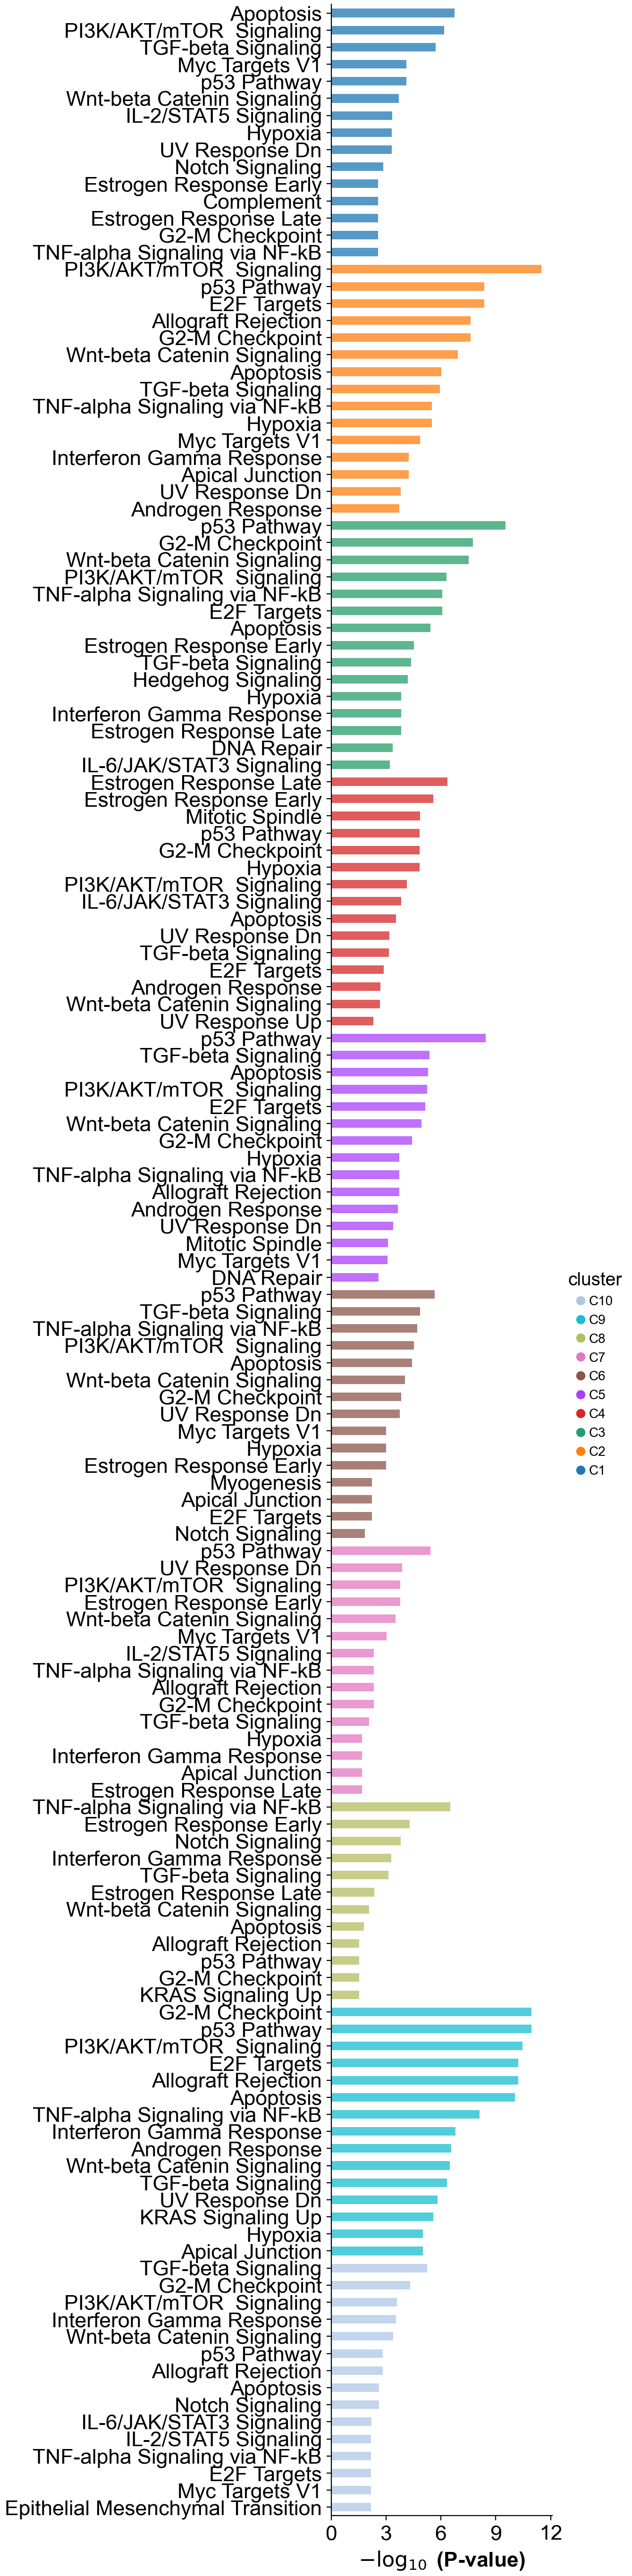

In [117]:
ax = barplot(enr_res_onco,
             #column="Adjusted P-value",
             column="P-value",
             group ='cluster',
             #group='Gene_set', # set group, so you could do a multi-sample/library comparsion
             size=0.5,
             top_term=15,
             #figsize=(10,6*len(enr.results[enr.results["P-value"] <= 0.05])/50),
             figsize=(3,35),
             #color=['red','purple','blue',"green"][::-1] # set colors for group
             color=hex_colors[0:10][::-1]
             #color = {'KEGG_2021_Human': 'salmon', 'MSigDB_Hallmark_2020':'darkblue'}
             )
plt.grid(False)
plt.savefig('./fig_cpr_rbg_stat_2/03.sc_sample/f13-oncogene-pathway_top15-2.pdf', bbox_inches='tight')

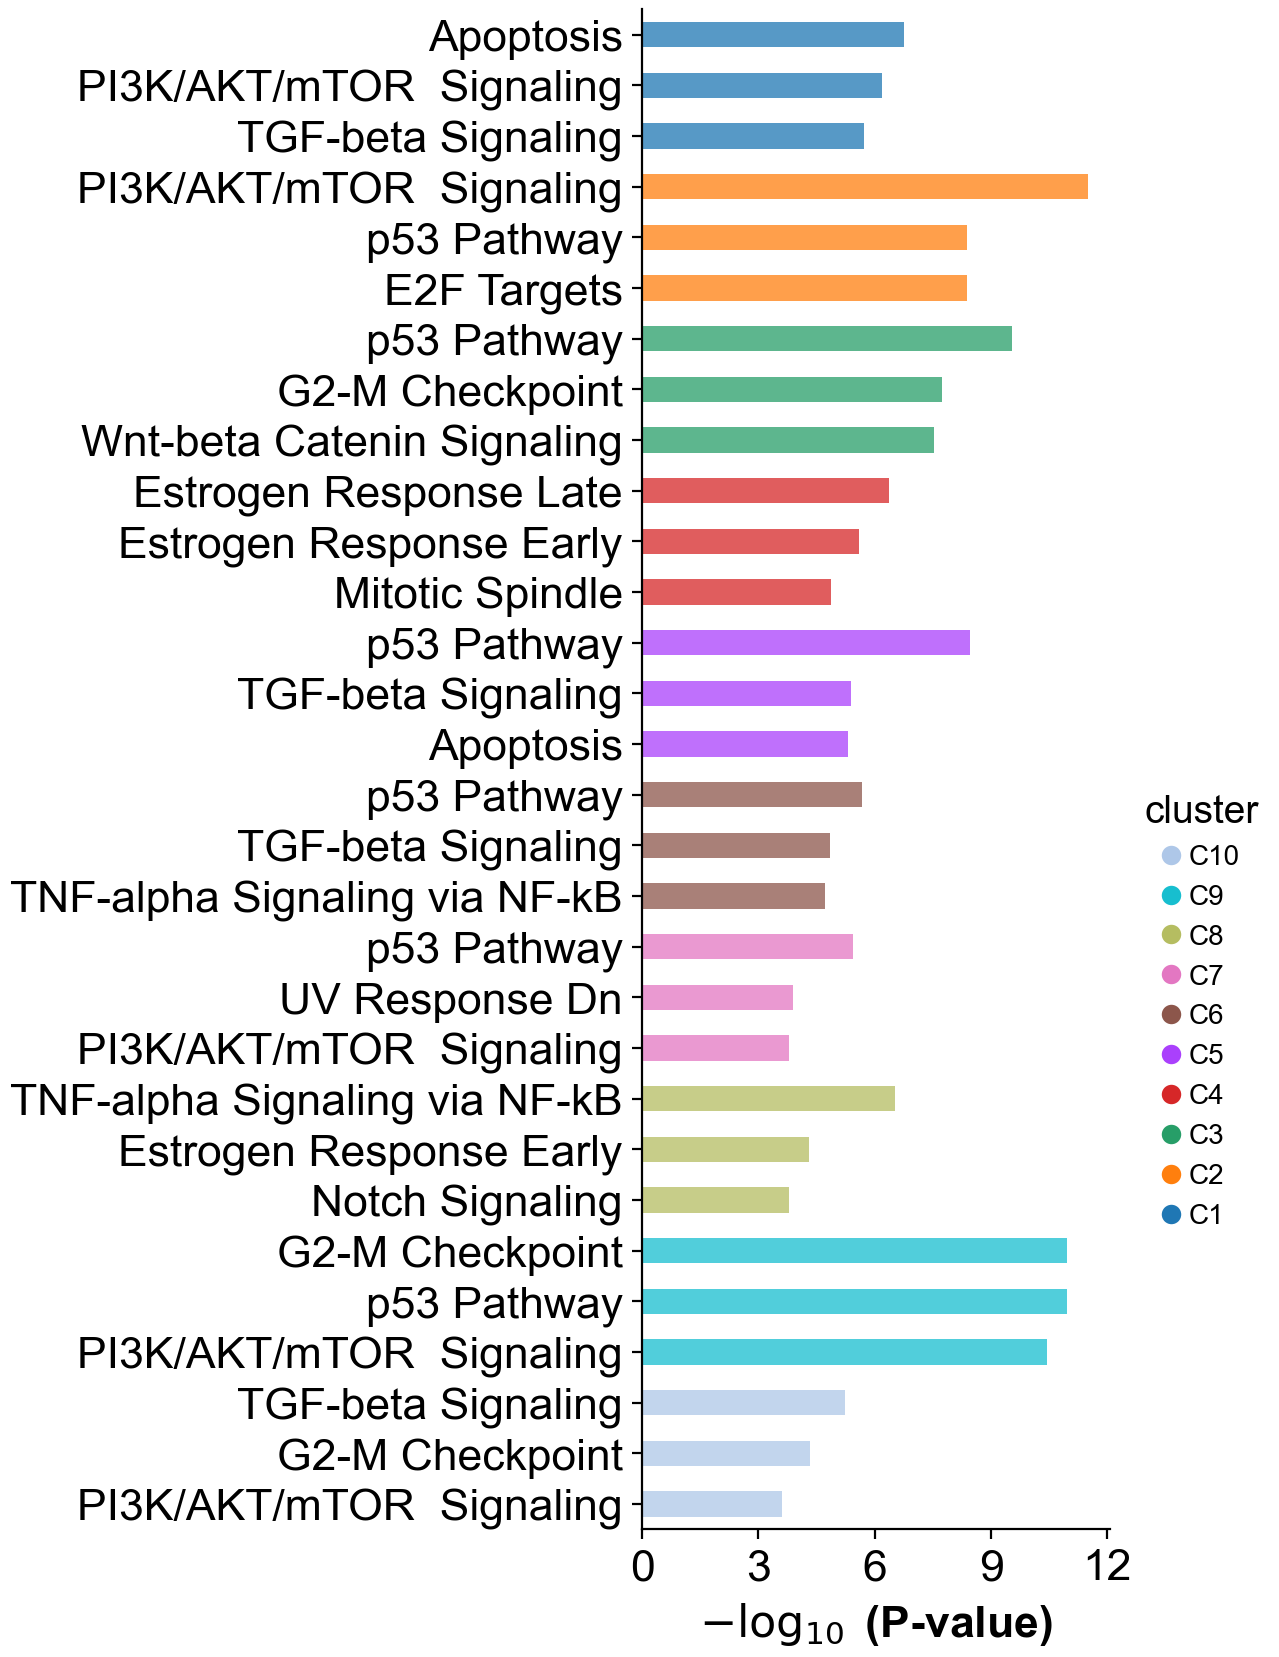

In [118]:
ax = barplot(enr_res_onco,
             #column="Adjusted P-value",
             column="P-value",
             group ='cluster',
             #group='Gene_set', # set group, so you could do a multi-sample/library comparsion
             size=0.5,
             top_term=3,
             #figsize=(10,6*len(enr.results[enr.results["P-value"] <= 0.05])/50),
             figsize=(3,10),
             #color=['red','purple','blue',"green"][::-1] # set colors for group
             color=hex_colors[0:10][::-1]
             #color = {'KEGG_2021_Human': 'salmon', 'MSigDB_Hallmark_2020':'darkblue'}
             )
plt.grid(False)
plt.savefig('./fig_cpr_rbg_stat_2/03.sc_sample/f13-oncogene-pathway_top15-3.pdf', bbox_inches='tight')